# Deep Neural Networks

Some of the modern CNN architectures were proposed as the state-of-the-art(SOTA) models and as foundations which inspired the development of the most of the current SOTA models.

They are:
* [GoogleNet](https://arxiv.org/abs/1409.4842)/Inception (winner of ILSVRC 2014)
* [ResNet](https://arxiv.org/abs/1512.03385) (winner of ILSVRC 2015)
* [DenseNet](https://arxiv.org/abs/1608.06993) (best paper award CVPR 2017)

## Preparation

In [1]:
# Standard libraries
import os
import numpy as np
import random
from PIL import Image
from types import SimpleNamespace

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline
import IPython
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf')
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.reset_orig()

# PyTorch
import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim

# TorchVision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms

In [2]:
DATASET_PATH = './data'
CHECKPOINT_PATH = './saved_models'

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

set_seed(42)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
import urllib.request
from urllib.error import HTTPError
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/"
pretrained_files = ["GoogleNet.ckpt", "ResNet.ckpt", "ResNetPreAct.ckpt", "DenseNet.ckpt",
                    "tensorboards/GoogleNet/events.out.tfevents.googlenet",
                    "tensorboards/ResNet/events.out.tfevents.resnet",
                    "tensorboards/ResNetPreAct/events.out.tfevents.resnetpreact",
                    "tensorboards/DenseNet/events.out.tfevents.densenet"]
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name)
    if "/" in file_name:
        os.makedirs(file_path.rsplit("/",1)[0], exist_ok=True)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n", e)

Using CIFAR10 dataset.

Make sure the **data preprocessed with a zero mean**.

First, calculate the mean and standard deviation of the dataset.

In [4]:
train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True)
DATA_MEANS = (train_dataset.data/255.0).mean(axis=(0,1,2))
DATA_STD = (train_dataset.data/255.0).std(axis=(0,1,2))

print("Data mean", DATA_MEANS)
print("Data std", DATA_STD)


Data mean [0.49139968 0.48215841 0.44653091]
Data std [0.24703223 0.24348513 0.26158784]


We will use the **calculated statistics** to define a `transforms.Normalize` module which will **normalize the data**.

We also need to augment the data in training by **data augmentation** to **reduce** the risk of **overfitting** and help the CNNs to **generalize** better. Specifically, we will use **random horizontal flipping** and **random cropping** to augment data.
* **`transforms.RandomHorizontalFlip`**: **flip each image horizontally by a chance 50%**. The **object class** usually **does not change** and we **don't** expect the **image information** depend on the **horizontal orientation**.
* **`transforms.RandomResizedCrop`**: **crop the image in a small range**, eventually changing the **aspect ratio** of the image and **scaling back** to the previous size. Thus, the **actual pixel size changed** but the **content and overall semantics stays the same**.




We would split the training dataset into training set and validation set for training the model and determining the early stopping. 

We would use the test dataset to test the trained model.

In [5]:
train_transform = transforms.Compose([
    # data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop((32,32), scale=(0.8,1.0), ratio=(0.9,1.1)),
    # image pixels to tensors
    transforms.ToTensor(),
    # normalize
    transforms.Normalize(DATA_MEANS, DATA_STD)
])

test_transform = transforms.Compose([
    # no need to data augmentation for test set, only for training
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEANS, DATA_STD)
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transform)
val_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transform)
set_seed(42)
train_set, _ = torch.utils.data.random_split(train_dataset, [45000, 5000])
set_seed(42)
_, val_set = torch.utils.data.random_split(val_dataset, [45000, 5000])

test_set = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=test_transform)

train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)

We can verify the normalization by printing the mean and standard deviation of a single batch.

The **mean** should be **close to 0** and the **standard deviation** should be **close to 1** for each channel.


In [6]:
imgs, _ = next(iter(train_loader))

print("Batch mean", imgs.mean(dim=[0,2,3]))
print("Batch std", imgs.std(dim=[0,2,3]))

Batch mean tensor([0.0231, 0.0006, 0.0005])
Batch std tensor([0.9865, 0.9849, 0.9868])


We can also visualize a few images from the training set and how they look after data augmentation.

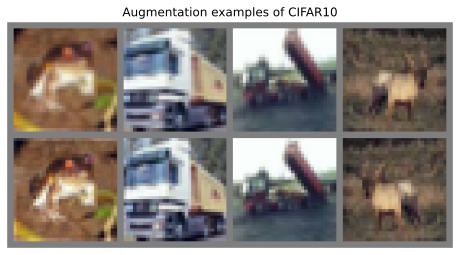

In [7]:
NUM_IMAGES = 4
images = [train_dataset[idx][0] for idx in range(NUM_IMAGES)]
orig_images = [Image.fromarray(train_dataset.data[idx]) for idx in range(NUM_IMAGES)]
orig_images = [test_transform(img) for img in orig_images]

img_grid = torchvision.utils.make_grid(
    torch.stack(images + orig_images, dim=0),
    nrow=4,
    normalize=True,
    pad_value=0.5
)
img_grid = img_grid.permute(1,2,0)

plt.figure(figsize=(8,8))
plt.title("Augmentation examples of CIFAR10")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

## PyTorch Lightning

**PyTorch lightning** **simplifies** the training, evaluation and testing **process** in PyTorch, **integrated** the **TensorBoard** and **saving** model **checkpoints** automatically.

In [8]:
try:
    import pytorch_lightning as pl
except ModuleNotFoundError:
    # install pytorch lightning manually
    pass

Set the seed first.

In [9]:
pl.seed_everything(42)

Seed set to 42


42

In PyTorch Lightning, we define **`pl.LightningModule`** to organize the code:
1. **Initialization**(`__init__`) to create all necessary parameters/models.
2. **Optimizers**(`configure_optimizers`) to create the optimizers, learning rate scheduler, etc.
3. **Training loop**(`training_step`) to define the loss calculation for a single batch.
4. **Validation loop**(`validation_step`) to define the loss calculation for a single batch on the validation set.
5. **Testing loop**(`test_step`) to define the loss calculation for a single batch on the test set.

In [10]:
class CIFARModule(pl.LightningModule):
    def __init__(self, model_name, model_hparams, optimizer_name, optimizer_hparams):
        super().__init__()
        self.save_hyperparameters()
        self.model = create_model(model_name, model_hparams)
        self.loss_module = nn.CrossEntropyLoss()
        self.example_input_array = torch.zeros((1,3,32,32), dtype=torch.float32)
    
    def forward(self, imgs):
        return self.model(imgs)

    def configure_optimizers(self):
        if self.hparams.optimizer_name == "Adam":
            optimizer = optim.AdamW(
                self.parameters(),
                **self.hparams.optimizer_hparams
            )
        elif self.hparams.optimizer_name == "SGD":
            optimizer = optim.SGD(
                self.parameters(),
                **self.hparams.optimizer_hparams
            )
        else:
            assert False, f"Unknown optimizer: {self.hparams.optimizer_name}"

        # reduce the learning rate by 0.1 after 100 and 150 epochs
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer,
            milestones=[100,150],
            gamma=0.1
        )

        return [optimizer], [scheduler]
    
    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        preds = self.model(imgs)
        loss = self.loss_module(preds, labels)
        acc = (preds.argmax(dim=-1) == labels).float().mean()

        self.log("train_acc", acc, on_step=False, on_epoch=True)
        self.log("train_loss", loss)
        
        # return tensor to call `.backward` on
        return loss
    
    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        preds = self.model(imgs).argmax(dim=-1)
        acc = (preds == labels).float().mean()

        self.log("val_acc", acc)

    def test_step(self, batch, batch_idx):
        imgs, labels = batch
        preds = self.model(imgs).argmax(dim=-1)
        acc = (preds == labels).float().mean()

        self.log("test_acc", acc)

Another important part of PyTorch Lightning is the concept of **callbacks**. 

Callbacks are self-contained functions that contain the **non-essential logic** of the Lightning Module. They are **usually called after finishing a training epoch**, but can also influence other parts of your training loop. For instance, we will use the following two pre-defined callbacks: `LearningRateMonitor` and `ModelCheckpoint`. 
* The learning rate monitor **adds** the **current learning rate** to our TensorBoard, which helps to **verify** that our **learning rate scheduler works correctly**. 
* The model checkpoint callback allows you to **customize the saving routine** of your checkpoints. For instance, how many checkpoints to keep, when to save, which metric to look out for, etc.

In [11]:
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

In [12]:
model_dict = {}

def create_model(model_name, model_hparams):
    if model_name in model_dict:
        return model_dict[model_name](**model_hparams)
    else:
        assert False, f"Model with name {model_name} not available"

In [13]:
act_fn_by_name = {
    "tanh": nn.Tanh,
    "relu": nn.ReLU,
    "leakyrelu": nn.LeakyReLU,
    "gelu": nn.GELU
}

The second most important module in PyTorch Lightning is the **`Trainer`**. The trainer is responsible to **execute the training steps** defined in the Lightning module and completes the framework. Similar to the Lightning module, you can **override** any key part that you don’t want to be automated, but the default settings are often the best practice to do. The most important functions we use below are:
* `**trainer.fit**`: Takes as input a lightning module, a training dataset, and an (optional) validation dataset. This function **trains the given module on the training dataset with occasional validation** (**default once per epoch**, can be changed)
* `**trainer.test**`: Takes as input a model and a dataset on which we want to test. It **returns the test metric** on the dataset.

For training and testing, we **don’t** have to **worry** about things like setting the model to eval mode (`model.eval()`) as this is all done automatically.

In [14]:
def train_model(model_name, save_name=None, **kwargs):
    if save_name is None:
        save_name = model_name

    trainer = pl.Trainer(
        default_root_dir=os.path.join(CHECKPOINT_PATH, save_name),
        accelerator="gpu" if str(device).startswith("mps") else "cpu",
        devices=1,
        max_epochs=180,
        callbacks=[
            ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc"),
            LearningRateMonitor("epoch")
        ],
        enable_progress_bar=True,
    )
    trainer.logger._log_graph = True
    trainer.logger._default_hp_metric = None

    pretrained_filename = os.path.join(CHECKPOINT_PATH, save_name + ".ckpt")
    if os.path.isfile(pretrained_filename):
        print(f"Found pretrained model at {pretrained_filename}, loading...")
        model = CIFARModule.load_from_checkpoint(pretrained_filename)
    else:
        pl.seed_everything(42)
        model = CIFARModule(model_name=model_name, **kwargs)
        trainer.fit(model, train_loader, val_loader)
        model = CIFARModule.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)
    
    val_result = trainer.test(model, val_loader, verbose=False)
    test_result = trainer.test(model, test_loader, verbose=False)
    result = {
        "test": test_result[0]["test_acc"],
        "val": val_result[0]["test_acc"]
    }

    return model, result

## Inception

In general, we will mainly focus on the concept of Inception instead of the specifics of the **GoogleNet**, as based on **Inception**, there have been many follow-up works (Inception-v2, Inception-v3, Inception-v4, Inception-ResNet,…). The **follow-up** works mainly focus on **increasing efficiency and enabling very deep Inception networks**.

An **Inception block** applies **four convolution blocks separately on the same feature map**: **a 1x1, 3x3, and 5x5 convolution, and a max pool operation**. This allows the network to look at the same data with **different receptive fields**. 

Of course, learning only 5x5 convolution would be theoretically more powerful. However, this is not only **more computation and memory heavy** but also tends to **overfit much easier**.

The **additional 1x1 convolutions** before the 3x3 and 5x5 convolutions are used for **dimensionality reduction**. This is especially **crucial** as the feature maps of all branches are merged afterward, and we **don’t want any explosion of feature size**. As 5x5 convolutions are 25 times more expensive than 1x1 convolutions, we can **save a lot of computation and parameters by reducing the dimensionality** before the large convolutions.

In [15]:
class InceptionBlock(nn.Module):

    def __init__(self, c_in, c_red : dict, c_out : dict, act_fn):
        """
        Inputs:
            c_in - Number of input feature maps from the previous layers
            c_red - Dictionary with keys "3x3" and "5x5" specifying the output of the dimensionality reducing 1x1 convolutions
            c_out - Dictionary with keys "1x1", "3x3", "5x5", and "max"
            act_fn - Activation class constructor (e.g. nn.ReLU)
        """
        super().__init__()

        # 1x1 convolution branch
        self.conv_1x1 = nn.Sequential(
            nn.Conv2d(c_in, c_out["1x1"], kernel_size=1),
            nn.BatchNorm2d(c_out["1x1"]),
            act_fn()
        )

        # 3x3 convolution branch
        self.conv_3x3 = nn.Sequential(
            nn.Conv2d(c_in, c_red["3x3"], kernel_size=1),
            nn.BatchNorm2d(c_red["3x3"]),
            act_fn(),
            nn.Conv2d(c_red["3x3"], c_out["3x3"], kernel_size=3, padding=1),
            nn.BatchNorm2d(c_out["3x3"]),
            act_fn()
        )

        # 5x5 convolution branch
        self.conv_5x5 = nn.Sequential(
            nn.Conv2d(c_in, c_red["5x5"], kernel_size=1),
            nn.BatchNorm2d(c_red["5x5"]),
            act_fn(),
            nn.Conv2d(c_red["5x5"], c_out["5x5"], kernel_size=5, padding=2),
            nn.BatchNorm2d(c_out["5x5"]),
            act_fn()
        )

        # Max-pool branch
        self.max_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1, stride=1),
            nn.Conv2d(c_in, c_out["max"], kernel_size=1),
            nn.BatchNorm2d(c_out["max"]),
            act_fn()
        )

    def forward(self, x):
        x_1x1 = self.conv_1x1(x)
        x_3x3 = self.conv_3x3(x)
        x_5x5 = self.conv_5x5(x)
        x_max = self.max_pool(x)
        x_out = torch.cat([x_1x1, x_3x3, x_5x5, x_max], dim=1)
        return x_out

The **GoogleNet** architecture **consists of stacking multiple Inception blocks with occasional max pooling to reduce the height and width of the feature maps**. 

The **original** GoogleNet was designed for image sizes of **ImageNet** (224x224 pixels) and had almost 7 million parameters. As we train on CIFAR10 with image sizes of 32x32, we don’t require such a heavy architecture, and instead, apply a reduced version. 

The number of channels for dimensionality reduction and output per filter (1x1, 3x3, 5x5, and max pooling) need to be manually specified and can be changed if interested. The general intuition is to **have the most filters for the 3x3 convolutions**, as they are powerful enough to take the context into account while requiring almost a third of the parameters of the 5x5 convolution.

In [16]:
class GoogleNet(nn.Module):

    def __init__(self, num_classes=10, act_fn_name="relu", **kwargs):
        super().__init__()
        self.hparams = SimpleNamespace(num_classes=num_classes,
                                       act_fn_name=act_fn_name,
                                       act_fn=act_fn_by_name[act_fn_name])
        self._create_network()
        self._init_params()

    def _create_network(self):
        # A first convolution on the original image to scale up the channel size
        self.input_net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            self.hparams.act_fn()
        )
        # Stacking inception blocks
        self.inception_blocks = nn.Sequential(
            InceptionBlock(64, c_red={"3x3": 32, "5x5": 16}, c_out={"1x1": 16, "3x3": 32, "5x5": 8, "max": 8}, act_fn=self.hparams.act_fn),
            InceptionBlock(64, c_red={"3x3": 32, "5x5": 16}, c_out={"1x1": 24, "3x3": 48, "5x5": 12, "max": 12}, act_fn=self.hparams.act_fn),
            nn.MaxPool2d(3, stride=2, padding=1),  # 32x32 => 16x16
            InceptionBlock(96, c_red={"3x3": 32, "5x5": 16}, c_out={"1x1": 24, "3x3": 48, "5x5": 12, "max": 12}, act_fn=self.hparams.act_fn),
            InceptionBlock(96, c_red={"3x3": 32, "5x5": 16}, c_out={"1x1": 16, "3x3": 48, "5x5": 16, "max": 16}, act_fn=self.hparams.act_fn),
            InceptionBlock(96, c_red={"3x3": 32, "5x5": 16}, c_out={"1x1": 16, "3x3": 48, "5x5": 16, "max": 16}, act_fn=self.hparams.act_fn),
            InceptionBlock(96, c_red={"3x3": 32, "5x5": 16}, c_out={"1x1": 32, "3x3": 48, "5x5": 24, "max": 24}, act_fn=self.hparams.act_fn),
            nn.MaxPool2d(3, stride=2, padding=1),  # 16x16 => 8x8
            InceptionBlock(128, c_red={"3x3": 48, "5x5": 16}, c_out={"1x1": 32, "3x3": 64, "5x5": 16, "max": 16}, act_fn=self.hparams.act_fn),
            InceptionBlock(128, c_red={"3x3": 48, "5x5": 16}, c_out={"1x1": 32, "3x3": 64, "5x5": 16, "max": 16}, act_fn=self.hparams.act_fn)
        )
        # Mapping to classification output
        self.output_net = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, self.hparams.num_classes)
        )

    def _init_params(self):
        # Based on our discussion in Tutorial 4, we should initialize the convolutions according to the activation function
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight, nonlinearity=self.hparams.act_fn_name)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.input_net(x)
        x = self.inception_blocks(x)
        x = self.output_net(x)
        return x

In [17]:
model_dict["GoogleNet"] = GoogleNet

In [18]:
googlenet_model, googlenet_results = train_model(
    model_name="GoogleNet",
    model_hparams={
        "num_classes": 10,
        "act_fn_name": "relu"
    },
    optimizer_name="Adam",
    optimizer_hparams={
        "lr": 1e-3,
        "weight_decay": 1e-4
    },
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.5.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint saved_models/GoogleNet.ckpt`


Found pretrained model at ./saved_models/GoogleNet.ckpt, loading...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

In [19]:
print("GoogleNet Results", googlenet_results)

GoogleNet Results {'test': 0.8970000147819519, 'val': 0.9028000235557556}


### Tensorboard log

In [20]:
%load_ext tensorboard

In [22]:
%tensorboard --logdir ./saved_models/tensorboards/GoogleNet

Reusing TensorBoard on port 6006 (pid 52080), started 0:00:47 ago. (Use '!kill 52080' to kill it.)

## ResNet

The [ResNet](https://arxiv.org/abs/1512.03385) paper is one of [**the most cited AI papers**](https://www.natureindex.com/news-blog/google-scholar-reveals-most-influential-papers-research-citations-twenty-twenty), and has been the foundation for neural networks with more than 1,000 layers. Despite its simplicity, the idea of **residual connections** is highly effective as it supports stable gradient propagation through the network. 

There have been many variants of ResNet proposed, which mostly concern the function 
$F$, or operations applied on the sum. We look at two of them: the original ResNet block, and the [Pre-Activation ResNet block](https://arxiv.org/abs/1603.05027). 

The original **ResNet** block **applies a non-linear activation function**, usually ReLU, **after the skip connection**. In contrast, the **pre-activation ResNet** block applies the **non-linearity at the beginning of $F$**. 

Both have their advantages and disadvantages. For **very deep network**, however, the **pre-activation ResNet** has shown to **perform better** as the gradient flow is guaranteed to have the identity matrix as calculated above, and is not harmed by any non-linear activation applied to it.

Let’s start with the original ResNet block. One special case we have to handle is when we want to **reduce the image dimensions in terms of width and height**.

The original implementation used an identity mapping with stride 2 and padded additional feature dimensions with 0. However, the **more common implementation** is to use a **1x1 convolution with stride 2** as it allows us to **change the feature dimensionality while being efficient in parameter and computation cost**.

In [36]:
class ResNetBlock(nn.Module):
    def __init__(self, c_in, act_fn, subsample=False, c_out=1):
        super().__init__()
        if not subsample:
            c_out = c_in
        
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, stride=1 if not subsample else 2, bias=False),
            nn.BatchNorm2d(c_out),
            act_fn(),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out)
        )

        # 1x1 convolution with stride 2
        self.downsample = nn.Conv2d(c_in, c_out, kernel_size=1, stride=2) if subsample else None
        self.act_fn = act_fn()
    
    def forward(self, x):
        z = self.net(x)
        if self.downsample is not None:
            x = self.downsample(x)
        out = z + x
        out = self.act_fn(out)
        return out

The second block we implement is the pre-activation ResNet block. For this, we have to **change the order** of layer in `self.net`, and **do not apply** an activation function on the output. Additionally, the downsampling operation has to apply a non-linearity as well as the input, $x_l$
, has not been processed by a non-linearity yet

In [37]:
class PreActResNetBlock(nn.Module):

    def __init__(self, c_in, act_fn, subsample=False, c_out=-1):
        super().__init__()
        if not subsample:
            c_out = c_in

        # Network representing F
        self.net = nn.Sequential(
            nn.BatchNorm2d(c_in),
            act_fn(),
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, stride=1 if not subsample else 2, bias=False),
            nn.BatchNorm2d(c_out),
            act_fn(),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False)
        )

        # 1x1 convolution can apply non-linearity as well, but not strictly necessary
        self.downsample = nn.Sequential(
            nn.BatchNorm2d(c_in),
            act_fn(),
            nn.Conv2d(c_in, c_out, kernel_size=1, stride=2, bias=False)
        ) if subsample else None

    def forward(self, x):
        z = self.net(x)
        if self.downsample is not None:
            x = self.downsample(x)
        out = z + x
        return out

In [38]:
resnet_blocks_by_name = {
    "ResNetBlock": ResNetBlock,
    "PreActResNetBlock": PreActResNetBlock
}

The overall ResNet architecture consists of stacking multiple ResNet blocks, of which some are downsampling the input. When talking about ResNet blocks in the whole network, we usually group them by the same output shape. Hence, if we say the ResNet has [3,3,3] blocks, it means that we have 3 times a group of 3 ResNet blocks, where a subsampling is taking place in the fourth and seventh block.

The three groups operate on the resolutions $32\times32$, $16\times16$ and $8\times8$.

In [39]:
class ResNet(nn.Module):

    def __init__(self, num_classes=10, num_blocks=[3,3,3], c_hidden=[16,32,64], act_fn_name="relu", block_name="ResNetBlock", **kwargs):
        """
        Inputs:
            num_classes - Number of classification outputs (10 for CIFAR10)
            num_blocks - List with the number of ResNet blocks to use. The first block of each group uses downsampling, except the first.
            c_hidden - List with the hidden dimensionalities in the different blocks. Usually multiplied by 2 the deeper we go.
            act_fn_name - Name of the activation function to use, looked up in "act_fn_by_name"
            block_name - Name of the ResNet block, looked up in "resnet_blocks_by_name"
        """
        super().__init__()
        assert block_name in resnet_blocks_by_name
        self.hparams = SimpleNamespace(num_classes=num_classes,
                                       c_hidden=c_hidden,
                                       num_blocks=num_blocks,
                                       act_fn_name=act_fn_name,
                                       act_fn=act_fn_by_name[act_fn_name],
                                       block_class=resnet_blocks_by_name[block_name])
        self._create_network()
        self._init_params()

    def _create_network(self):
        c_hidden = self.hparams.c_hidden

        # A first convolution on the original image to scale up the channel size
        if self.hparams.block_class == PreActResNetBlock: # => Don't apply non-linearity on output
            self.input_net = nn.Sequential(
                nn.Conv2d(3, c_hidden[0], kernel_size=3, padding=1, bias=False)
            )
        else:
            self.input_net = nn.Sequential(
                nn.Conv2d(3, c_hidden[0], kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c_hidden[0]),
                self.hparams.act_fn()
            )

        # Creating the ResNet blocks
        blocks = []
        for block_idx, block_count in enumerate(self.hparams.num_blocks):
            for bc in range(block_count):
                subsample = (bc == 0 and block_idx > 0) # Subsample the first block of each group, except the very first one.
                blocks.append(
                    self.hparams.block_class(c_in=c_hidden[block_idx if not subsample else (block_idx-1)],
                                             act_fn=self.hparams.act_fn,
                                             subsample=subsample,
                                             c_out=c_hidden[block_idx])
                )
        self.blocks = nn.Sequential(*blocks)

        # Mapping to classification output
        self.output_net = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(c_hidden[-1], self.hparams.num_classes)
        )

    def _init_params(self):
        # Based on our discussion in Tutorial 4, we should initialize the convolutions according to the activation function
        # Fan-out focuses on the gradient distribution, and is commonly used in ResNets
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity=self.hparams.act_fn_name)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.input_net(x)
        x = self.blocks(x)
        x = self.output_net(x)
        return x

In [40]:
model_dict["ResNet"] = ResNet

Finally, we can train our ResNet models. One **difference** to the GoogleNet training is that we **explicitly use SGD with Momentum** as optimizer instead of Adam. 

Adam often leads to a slightly worse accuracy on plain, shallow ResNets. It is not 100% clear why Adam performs worse in this context, but one possible explanation is related to **ResNet’s loss surface**. ResNet has been shown to produce **smoother loss surfaces** than networks without skip connection.

On **smooth surfaces** like the one on the right, we **might not require an adaptive learning rate** as Adam provides. Instead, Adam can get stuck in local optima while SGD finds the wider minima that tend to generalize better.

In [41]:
resnet_model, resnet_results = train_model(
    model_name="ResNet",
    model_hparams={
        "num_classes": 10,
        "c_hidden": [16,32,64],
        "num_blocks": [3,3,3],
        "act_fn_name": "relu",
    },
    optimizer_name="SGD",
    optimizer_hparams={
        "lr": 0.1,
        "momentum": 0.9,
        "weight_delay": 1e-4
    }
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.5.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint saved_models/ResNet.ckpt`


Found pretrained model at ./saved_models/ResNet.ckpt, loading...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

In [42]:
resnetpreact_model, resnetpreact_results = train_model(
    model_name="ResNet",
    model_hparams={
        "num_classes": 10,
        "c_hidden": [16,32,64],
        "num_blocks": [3,3,3],
        "act_fn_name": "relu",
        "block_name": "PreActResNetBlock"},
    optimizer_name="SGD",
    optimizer_hparams={
        "lr": 0.1,
        "momentum": 0.9,
        "weight_decay": 1e-4
    },
    save_name="ResNetPreAct"
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.5.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint saved_models/ResNetPreAct.ckpt`


Found pretrained model at ./saved_models/ResNetPreAct.ckpt, loading...


Testing: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

### Tensorboard log

In [43]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [47]:
%tensorboard --logdir ./saved_models/tensorboards/ResNet/

Reusing TensorBoard on port 6008 (pid 61085), started 0:00:02 ago. (Use '!kill 61085' to kill it.)

## DenseNet

[DenseNet](https://arxiv.org/abs/1608.06993) is another architecture for enabling **very deep** neural networks and takes a slightly different perspective on residual connections. Instead of modeling the difference between layers, DenseNet considers **residual connections as a possible way to reuse features across layers**, removing any necessity to learn redundant feature maps. If we go deeper into the network, the model learns abstract features to recognize patterns. However, some complex patterns consist of a combination of abstract features (e.g. hand, face, etc.), and low-level features (e.g. edges, basic color, etc.). To find these low-level features in the deep layers, standard CNNs have to learn copy such feature maps, which wastes a lot of parameter complexity. DenseNet provides an **efficient** way of **reusing features by having each convolution depends on all previous input features**, but **add only a small amount of filters** to it.

The **last** layer, called the **transition** layer, is responsible for **reducing the dimensionality of the feature maps in height, width, and channel size**. Although those technically break the identity backpropagation, there are only a few in a network so that it doesn’t affect the gradient flow much.

We split the implementation of the layers in DenseNet into **three** parts: 
* a `DenseLayer`,
* a `DenseBlock`,
* a `TransitionLayer`. 

The module `DenseLayer` implements a **single layer inside a dense block**. It applies a 1x1 convolution for dimensionality reduction with a subsequential 3x3 convolution. The output channels are concatenated to the originals and returned. Note that we apply the Batch Normalization as the first layer of each block. This allows slightly different activations for the same features to different layers, depending on what is needed. 

In [48]:
class DenseLayer(nn.Module):
    def __init__(self, c_in, bn_size, growth_rate, act_fn):
        super().__init__()

        self.net = nn.Sequential(
            nn.BatchNorm2d(c_in),
            act_fn(),
            nn.Conv2d(c_in, bn_size * growth_rate, kernel_size=1, bias=False),
            nn.BatchNorm2d(bn_size * growth_rate),
            act_fn(),
            nn.Conv2d(bn_size * growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)
        )


    def forward(self, x):
        out = self.net(x)
        out = torch.cat([out, x], dim=1)
        return out

The module `DenseBlock` summarizes **multiple** dense layers applied in sequence. Each dense layer takes as input the **original input concatenated with all previous** layers’ feature maps:

In [49]:
class DenseBlock(nn.Module):
    def __init__(self, c_in, num_layers, bn_size, growth_rate, act_fn):
        super().__init__()
        layers = []
        
        for layer_idx in range(num_layers):
            layers.append(
                DenseLayer(
                    c_in=c_in + layer_idx * growth_rate,
                    bn_size=bn_size,
                    growth_rate=growth_rate,
                    act_fn=act_fn,
                )
            )
        self.block = nn.Sequential(*layers)
    
    def forward(self, x):
        out = self.block(x)
        return out

Finally, the `TransitionLayer` takes as input the final output of a dense block and **reduces its channel dimensionality** using a 1x1 convolution. To reduce the height and width dimension, we take a slightly **different** approach than in ResNet and apply **an average pooling with kernel size 2 and stride 2**. This is because we don’t have an additional connection to the output that would consider the full 2x2 patch instead of a single value. Besides, it is more parameter efficient than using a 3x3 convolution with stride 2. 

In [50]:
class TransitionLayer(nn.Module):
    def __init__(self, c_in, c_out, act_fn):
        super().__init__()
        self.transition = nn.Sequential(
            nn.BatchNorm2d(c_in),
            act_fn(),
            nn.Conv2d(c_in, c_out, kernel_size=1, bias=False),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.transition(x)

Now we can put everything together and create our DenseNet. 

To specify the number of layers, we use a similar notation as in ResNets and pass on a list of ints representing the number of layers per block. After each dense block except the last one, we apply a transition layer to reduce the dimensionality by 2.

In [51]:
class DenseNet(nn.Module):
    def __init__(self, num_classes=10, num_layers=[6,6,6,6], bn_size=2, growth_rate=16, act_fn_name="relu", **kwargs):
        super().__init__()
        self.hparams = SimpleNamespace(
            num_classes=num_classes,
            num_layers=num_layers,
            bn_size=bn_size,
            growth_rate=growth_rate,
            act_fn_name=act_fn_name,
            act_fn=act_fn_by_name[act_fn_name]
        )
        self._create_network()
        self._init_params()

    def _create_network(self):
        c_hidden = self.hparams.growth_rate * self.hparams.bn_size

        self.input_net = nn.Sequential(
            nn.Conv2d(3, c_hidden, kernel_size=3, padding=1)
        )

        blocks = []
        for block_idx, num_layers in enumerate(self.hparams.num_layers):
            blocks.append(
                DenseBlock(
                    c_in=c_hidden,
                    num_layers=num_layers,
                    bn_size=self.hparams.bn_size,
                    growth_rate=self.hparams.growth_rate,
                    act_fn=self.hparams.act_fn
                )
            )
            c_hidden = c_hidden + num_layers * self.hparams.growth_rate
            if block_idx < len(self.hparams.num_layers)-1:
                blocks.append(
                    TransitionLayer(
                        c_in=c_hidden,
                        c_out=c_hidden//2,
                        act_fn=self.hparams.act_fn
                    )
                )
                c_hidden = c_hidden // 2
        
        self.blocks = nn.Sequential(*blocks)

        self.output_net = nn.Sequential(
            nn.BatchNorm2d(c_hidden),
            self.hparams.act_fn(),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(c_hidden, self.hparams.num_classes)
        )

    def _init_params(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity=self.hparams.act_fn_name)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        x = self.input_net(x)
        x = self.blocks(x)
        x = self.output_net(x)
        return x

In [52]:
model_dict["DenseNet"] = DenseNet

In [53]:
densenet_model, densenet_results = train_model(
    model_name="DenseNet",
    model_hparams={
        "num_classes": 10,
        "num_layers": [6,6,6,6],
        "bn_size": 2,
        "growth_rate": 16,
        "act_fn_name": "relu"
    },
    optimizer_name="Adam",
    optimizer_hparams={
        "lr": 1e-3,
        "weight_decay": 1e-4
    }
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.5.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint saved_models/DenseNet.ckpt`


Found pretrained model at ./saved_models/DenseNet.ckpt, loading...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

### Tensorboard log

In [55]:
%tensorboard --logdir ./saved_models/tensorboards/DenseNet

Reusing TensorBoard on port 6009 (pid 83408), started 0:00:07 ago. (Use '!kill 83408' to kill it.)

## Conclusion and Comparison

In [56]:
%%html
<style>
th {font-size: 120%;}
td {font-size: 120%}
</style>

In [57]:
import tabulate
from IPython.display import display, HTML
all_models = [
    ("GoogleNet", googlenet_results, googlenet_model),
    ("ResNet", resnet_results, resnet_model),
    ("ResNetPreAct", resnetpreact_results, resnetpreact_model),
    ("DenseNet", densenet_results, densenet_model)
]
table =[[model_name,
          f"{100.0*model_results['val']:4.2f}%",
          f"{100.0*model_results['test']:4.2f}%",
          "{:,}".format(sum([np.prod(p.shape) for p in model.parameters()]))]
         for model_name, model_results, model in all_models]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["Model", "Val Accuracy", "Test Accuracy", "Num Parameters"])))

Model,Val Accuracy,Test Accuracy,Num Parameters
GoogleNet,90.28%,89.70%,"260,650"
ResNet,91.40%,91.06%,"272,378"
ResNetPreAct,91.54%,91.07%,"272,250"
DenseNet,90.44%,90.23%,"239,146"


We can conclude that for **shallow** networks, the **place of the activation function does not** seem to be **crucial**, although papers have reported the **contrary** for very **deep** networks.

In general, we can conclude that **ResNet** is a **simple**, but **powerful** architecture. If we would apply the models on more complex tasks with larger images and more layers inside the networks, we would likely see a bigger gap between GoogleNet and skip-connection architectures like ResNet and DenseNet.

If we would apply the models on more complex tasks with larger images and more layers inside the networks, we would likely see a bigger gap between GoogleNet and skip-connection architectures like ResNet and DenseNet. A comparison with deeper models on CIFAR10 can be for example found [here](https://github.com/kuangliu/pytorch-cifar). Interestingly, DenseNet outperforms the original ResNet on their setup but comes closely behind the Pre-Activation ResNet. The best model, a [Dual Path Network](https://arxiv.org/abs/1707.01629), is actually a combination of ResNet and DenseNet showing that both offer different advantages.


## Which model to choose?

Usually, **starting** with a **ResNet** is a good idea given the superior performance of the CIFAR dataset and its simple implementation. Besides, for the parameter number we have chosen here, ResNet is the fastest as DenseNet and GoogleNet have many more layers that are applied in sequence in our primitive implementation. However, if you have a really **difficult** task, such as semantic segmentation on HD images, more complex **variants** of **ResNet** and **DenseNet** are recommended.